In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [4]:
# Load cleaned reviews
df = pd.read_csv('../data/raw/all_reviews.csv')
print(f"✅ Data loaded! Shape: {df.shape}")
print(f"\nReviews per bank:")
print(df['bank'].value_counts())
print(f"\nSample:")
df.head(3)

✅ Data loaded! Shape: (1449, 5)

Reviews per bank:
bank
Bank of Abyssinia              498
Dashen Bank                    495
Commercial Bank of Ethiopia    456
Name: count, dtype: int64

Sample:


,review,rating,date,bank,source
0,🤙🏼🤙🏼,5,2026-05-16,Commercial Bank of Ethiopia,Google Play
1,worst,1,2026-05-16,Commercial Bank of Ethiopia,Google Play
2,this app very full,5,2026-05-15,Commercial Bank of Ethiopia,Google Play


In [5]:
# ============================================
# SENTIMENT ANALYSIS USING VADER
# Tool Selection Rationale:
# - VADER is optimized for short social media text
# - No training required, works out of the box
# - Returns compound score (-1 to +1)
# - Fast enough for 1,449 reviews
# ============================================

analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    try:
        return analyzer.polarity_scores(str(text))['compound']
    except:
        return 0.0

def classify_sentiment(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

print("Running sentiment analysis...")
df['sentiment_score'] = df['review'].apply(get_sentiment_score)
df['sentiment_label'] = df['sentiment_score'].apply(classify_sentiment)

print("✅ Sentiment analysis complete!")
print(f"\nOverall sentiment distribution:")
print(df['sentiment_label'].value_counts())
print(f"\nSentiment score statistics:")
print(df['sentiment_score'].describe().round(4))

Running sentiment analysis...
✅ Sentiment analysis complete!

Overall sentiment distribution:
sentiment_label
positive    764
neutral     433
negative    252
Name: count, dtype: int64

Sentiment score statistics:
count    1449.0000
mean        0.2086
std         0.4369
min        -0.9371
25%         0.0000
50%         0.2382
75%         0.5859
max         0.9848
Name: sentiment_score, dtype: float64


In [6]:
# Aggregate sentiment by bank
print("=== SENTIMENT BY BANK ===\n")

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    print(f"{bank}:")
    print(f"  Total reviews: {len(bank_df)}")
    print(f"  Avg sentiment score: {bank_df['sentiment_score'].mean():.4f}")
    print(f"  Positive: {(bank_df['sentiment_label']=='positive').sum()} ({(bank_df['sentiment_label']=='positive').mean()*100:.1f}%)")
    print(f"  Neutral:  {(bank_df['sentiment_label']=='neutral').sum()} ({(bank_df['sentiment_label']=='neutral').mean()*100:.1f}%)")
    print(f"  Negative: {(bank_df['sentiment_label']=='negative').sum()} ({(bank_df['sentiment_label']=='negative').mean()*100:.1f}%)")
    print()

=== SENTIMENT BY BANK ===

Commercial Bank of Ethiopia:
  Total reviews: 456
  Avg sentiment score: 0.2383
  Positive: 258 (56.6%)
  Neutral:  137 (30.0%)
  Negative: 61 (13.4%)

Bank of Abyssinia:
  Total reviews: 498
  Avg sentiment score: 0.1250
  Positive: 219 (44.0%)
  Neutral:  171 (34.3%)
  Negative: 108 (21.7%)

Dashen Bank:
  Total reviews: 495
  Avg sentiment score: 0.2652
  Positive: 287 (58.0%)
  Neutral:  125 (25.3%)
  Negative: 83 (16.8%)



In [7]:
# Mean sentiment score per star rating per bank
print("=== MEAN SENTIMENT BY STAR RATING ===\n")
rating_sentiment = df.groupby(['bank', 'rating'])['sentiment_score'].mean().round(4)
print(rating_sentiment)

=== MEAN SENTIMENT BY STAR RATING ===

bank                         rating
Bank of Abyssinia            1        -0.1796
                             2         0.0222
                             3         0.1954
                             4         0.3241
                             5         0.3223
Commercial Bank of Ethiopia  1        -0.0970
                             2         0.1762
                             3        -0.0750
                             4         0.1693
                             5         0.3908
Dashen Bank                  1        -0.1837
                             2        -0.0104
                             3         0.2543
                             4         0.3382
                             5         0.4456
Name: sentiment_score, dtype: float64


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['review'].apply(clean_text)

# Define themes and their keywords
THEMES = {
    'Transaction Performance': ['transfer', 'slow', 'fast', 'transaction', 
                                 'payment', 'speed', 'loading', 'delay'],
    'Account Access Issues': ['login', 'password', 'otp', 'access', 
                               'error', 'fingerprint', 'blocked', 'unlock'],
    'App Stability': ['crash', 'bug', 'update', 'fix', 'freeze', 
                       'stop', 'working', 'broken', 'restart'],
    'UI & Design': ['interface', 'design', 'easy', 'simple', 'navigation',
                     'user', 'friendly', 'ui', 'look', 'experience'],
    'Customer Support': ['support', 'service', 'help', 'response', 
                          'agent', 'call', 'staff', 'complaint']
}

def assign_theme(text):
    text = str(text).lower()
    scores = {}
    for theme, keywords in THEMES.items():
        scores[theme] = sum(1 for kw in keywords if kw in text)
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'General Feedback'

df['identified_theme'] = df['clean_review'].apply(assign_theme)

print("✅ Thematic analysis complete!")
print(f"\nTheme distribution:")
print(df['identified_theme'].value_counts())

✅ Thematic analysis complete!

Theme distribution:
identified_theme
General Feedback           950
Transaction Performance    175
App Stability              151
UI & Design                 93
Customer Support            40
Account Access Issues       40
Name: count, dtype: int64


In [13]:
print("=== TOP KEYWORDS PER BANK ===\n")

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=10,
        ngram_range=(1, 2),
        min_df=2
    )
    
    try:
        X = vectorizer.fit_transform(bank_df['clean_review'])
        keywords = vectorizer.get_feature_names_out()
        scores = X.toarray().sum(axis=0)
        keyword_df = pd.DataFrame({'keyword': keywords, 'score': scores})
        keyword_df = keyword_df.sort_values('score', ascending=False)
        
        print(f"{bank}:")
        print(keyword_df.to_string(index=False))
        print()
    except Exception as e:
        print(f"  Error: {e}")

=== TOP KEYWORDS PER BANK ===

Commercial Bank of Ethiopia:
    keyword     score
        app 89.789002
       good 57.424052
       nice 23.798120
       best 23.351781
        cbe 22.147153
application 19.919326
       work 19.775761
     update 19.286375
       bank 18.822856
    working 16.917202

Bank of Abyssinia:
keyword      score
    app 121.607310
   good  47.538969
   bank  34.005892
    boa  27.994505
   best  27.734403
   work  25.698050
banking  19.832696
    use  19.744070
  worst  19.673301
 mobile  19.492248

Dashen Bank:
    keyword      score
        app 138.666588
       bank  47.133268
       good  43.933203
     dashen  31.693331
       best  31.674213
        use  28.478753
    banking  26.776479
      super  21.063595
dashen bank  16.730574
  super app  14.137619



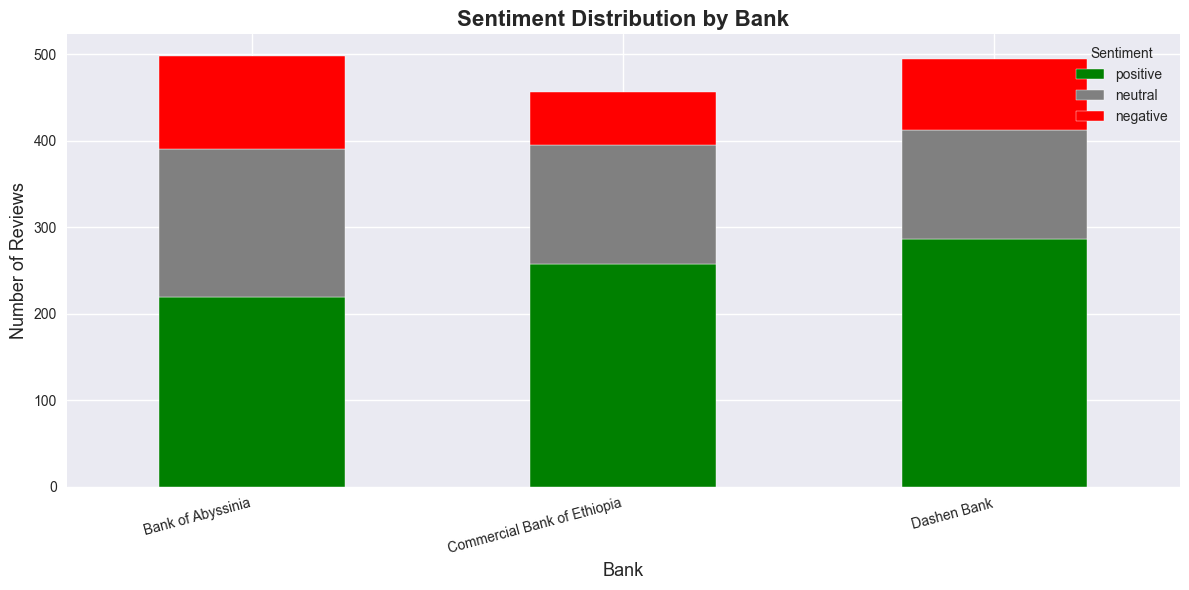

✅ Plot 1 saved!


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

sentiment_counts = df.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_counts = sentiment_counts[['positive', 'neutral', 'negative']]

sentiment_counts.plot(
    kind='bar',
    stacked=True,
    color=['green', 'grey', 'red'],
    edgecolor='white',
    ax=ax
)

ax.set_title('Sentiment Distribution by Bank', fontsize=16, fontweight='bold')
ax.set_xlabel('Bank', fontsize=13)
ax.set_ylabel('Number of Reviews', fontsize=13)
ax.legend(title='Sentiment', loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.savefig('../data/raw/sentiment_distribution.png', dpi=150)
plt.show()
print("✅ Plot 1 saved!")

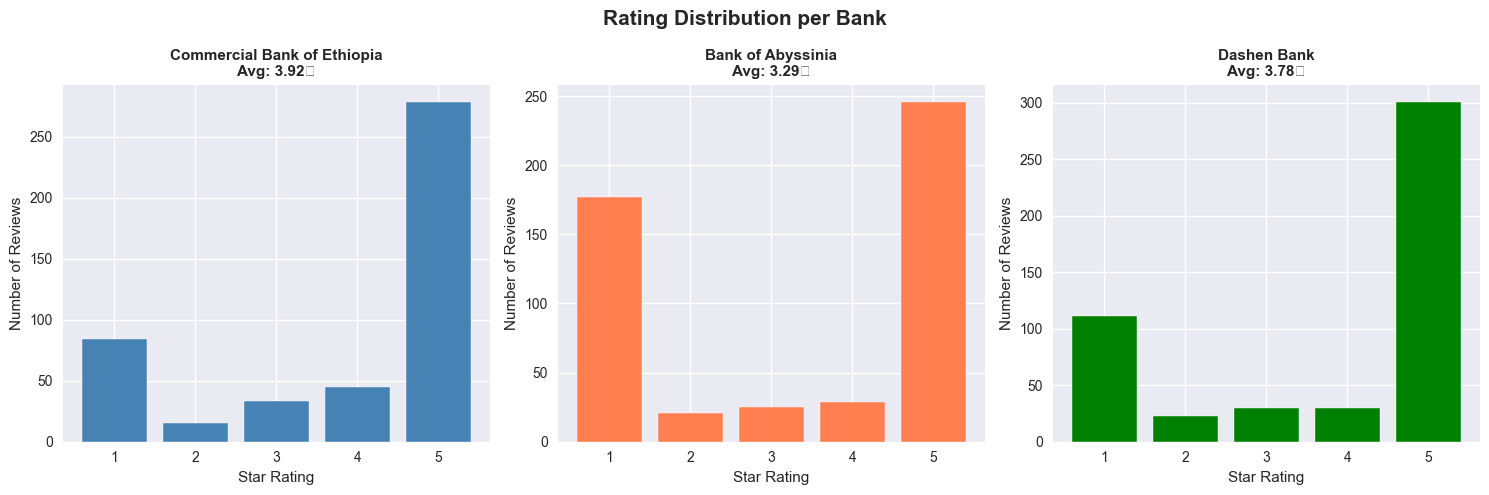

✅ Plot 2 saved!


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

banks = df['bank'].unique()
colors = ['steelblue', 'coral', 'green']

for i, (bank, color) in enumerate(zip(banks, colors)):
    bank_df = df[df['bank'] == bank]
    rating_counts = bank_df['rating'].value_counts().sort_index()
    
    axes[i].bar(rating_counts.index, rating_counts.values, 
                color=color, edgecolor='white')
    axes[i].set_title(f'{bank}\nAvg: {bank_df["rating"].mean():.2f}⭐', 
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Star Rating')
    axes[i].set_ylabel('Number of Reviews')
    axes[i].set_xticks([1, 2, 3, 4, 5])

plt.suptitle('Rating Distribution per Bank', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/raw/rating_distribution.png', dpi=150)
plt.show()
print("✅ Plot 2 saved!")

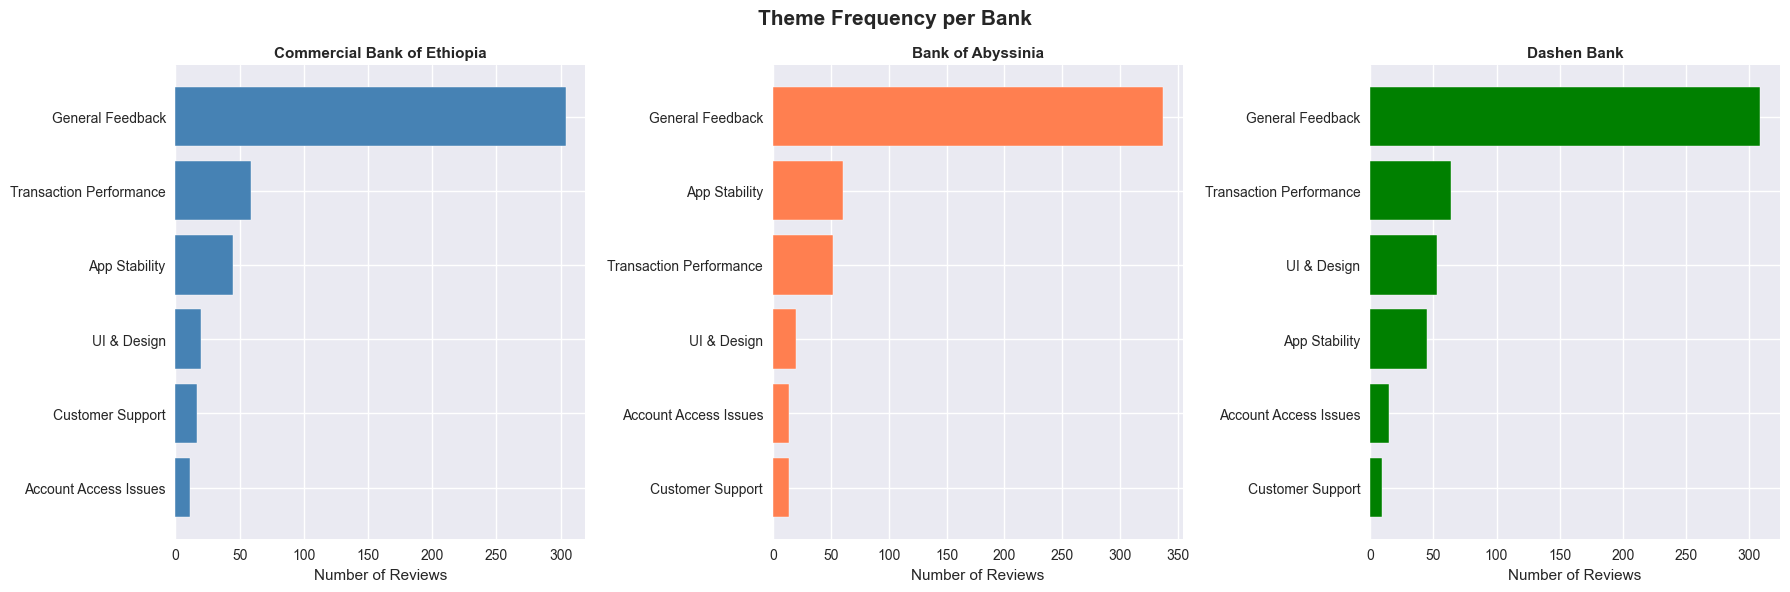

✅ Plot 3 saved!


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

banks = df['bank'].unique()
colors = ['steelblue', 'coral', 'green']

for i, (bank, color) in enumerate(zip(banks, colors)):
    bank_df = df[df['bank'] == bank]
    theme_counts = bank_df['identified_theme'].value_counts()
    
    axes[i].barh(theme_counts.index, theme_counts.values,
                 color=color, edgecolor='white')
    axes[i].set_title(f'{bank}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Number of Reviews')
    axes[i].invert_yaxis()

plt.suptitle('Theme Frequency per Bank', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/raw/theme_frequency.png', dpi=150)
plt.show()
print("✅ Plot 3 saved!")

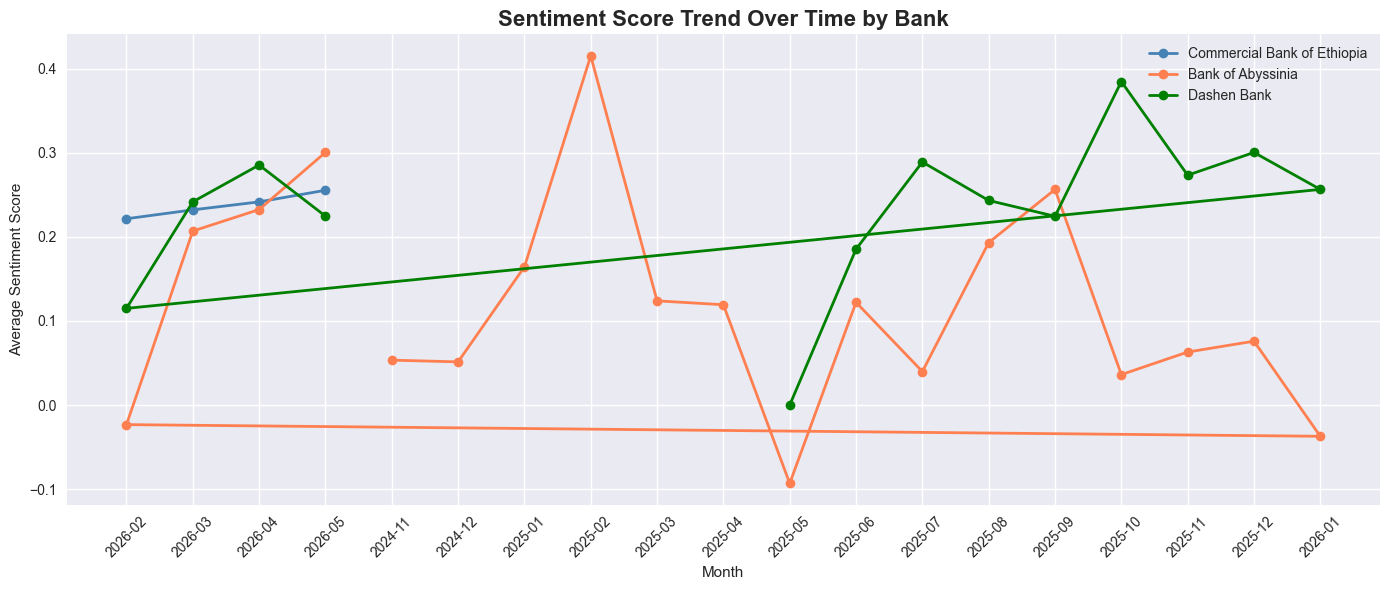

✅ Plot 4 saved!


In [17]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

monthly_sentiment = df.groupby(['month', 'bank'])['sentiment_score'].mean().reset_index()
monthly_sentiment['month'] = monthly_sentiment['month'].astype(str)

plt.figure(figsize=(14, 6))

colors = {'Commercial Bank of Ethiopia': 'steelblue',
          'Bank of Abyssinia': 'coral',
          'Dashen Bank': 'green'}

for bank in df['bank'].unique():
    bank_data = monthly_sentiment[monthly_sentiment['bank'] == bank]
    plt.plot(bank_data['month'], bank_data['sentiment_score'],
             marker='o', label=bank, color=colors[bank], linewidth=2)

plt.title('Sentiment Score Trend Over Time by Bank', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Sentiment Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/raw/sentiment_trend.png', dpi=150)
plt.show()
print("✅ Plot 4 saved!")

In [18]:
# Save final results with sentiment and themes
output_df = df[['review', 'rating', 'date', 'bank', 'source',
                 'sentiment_score', 'sentiment_label', 'identified_theme']].copy()

output_df.columns = ['review_text', 'rating', 'date', 'bank', 'source',
                      'sentiment_score', 'sentiment_label', 'identified_theme']

output_df['review_id'] = range(1, len(output_df) + 1)

output_df.to_csv('../data/raw/reviews_with_sentiment.csv', index=False)

print("✅ Results saved!")
print(f"Shape: {output_df.shape}")
print(f"\nSample:")
output_df.head(3)

✅ Results saved!
Shape: (1449, 9)

Sample:


,review_text,rating,date,bank,source,sentiment_score,sentiment_label,identified_theme,review_id
0,🤙🏼🤙🏼,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,0.7506,positive,General Feedback,1
1,worst,1,2026-05-16,Commercial Bank of Ethiopia,Google Play,-0.6249,negative,General Feedback,2
2,this app very full,5,2026-05-15,Commercial Bank of Ethiopia,Google Play,0.0000,neutral,General Feedback,3
